In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
data = pd.read_csv('/Users/aajinkyaingalkar/MNIST_Tensorflow_Keras/data/train.csv')

In [33]:
data = np.array(data)
n , m = data.shape
n, m
# data.head()

(42000, 785)

In [51]:
# train and test split
data_train = data[1000:n]
Y_train = data_train[:, 0]
print(Y_train.shape, Y_train)
X_train = data_train[:, 1:] / 255.0
data_test = data[0:1000]
Y_test = data_test[:, 0]
X_test = data_test[:, 1:] / 255.0
data_train

(41000,) [1 5 1 ... 7 6 9]


array([[1, 0, 0, ..., 0, 0, 0],
       [5, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [7, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0]], shape=(41000, 785))

In [ ]:
#Forward propagation
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, input_shape=(784,), activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
#Backward propagation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) 
#Model training
model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9164 - loss: 0.2792
Epoch 2/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.9642 - loss: 0.1159
Epoch 3/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 929us/step - accuracy: 0.9744 - loss: 0.0804
Epoch 4/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.9811 - loss: 0.0591
Epoch 5/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.9852 - loss: 0.0462
Epoch 6/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - accuracy: 0.9878 - loss: 0.0367
Epoch 7/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9894 - loss: 0.0318
Epoch 8/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9910 - loss: 0.0265
Epoch 9/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9929 - loss: 0.0211
Epoch 10/10
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step - accuracy: 0.9946 - loss: 0.0164


In [ ]:
#Evaluation Cross-entropy loss and accuracy are calculated on the test set to evaluate the model's performance. 
# The model's predictions are compared to the true labels in the test set, and metrics such as accuracy are computed to assess how well the model generalizes to unseen data.
model.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.9730 - loss: 0.1072


[0.1071520671248436, 0.9729999899864197]

In [85]:
#Predictions
predictions = model.predict(X_test)
print(predictions[100])
predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels[100])
print(Y_test[100])
print(X_test.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step
[1.1084535e-08 1.7397186e-09 5.1838299e-07 4.4181334e-08 4.0116432e-04
 5.8201743e-10 3.9492849e-12 1.5622561e-03 1.9732068e-05 9.9801624e-01]
9
9
(1000, 784)


Predicted digit: 9
Actual digit: 9


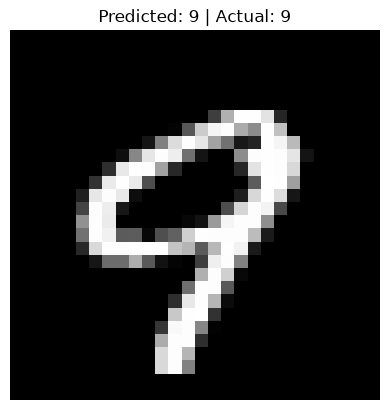

In [84]:
predicted_labels = np.argmax(predictions, axis=1)
sample_index = 100

print(f"Predicted digit: {predicted_labels[sample_index]}")
print(f"Actual digit: {Y_test[sample_index]}")

plt.imshow(X_test[sample_index].reshape(28, 28), cmap="gray")
plt.title(f"Predicted: {predicted_labels[sample_index]} | Actual: {Y_test[sample_index]}")
plt.axis("off")
plt.show()

In [86]:
tf.math.confusion_matrix(Y_test, predicted_labels)

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[107,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  92,   2,   0,   1,   0,   0,   0,   1,   0],
       [  0,   0, 121,   1,   0,   0,   0,   2,   0,   0],
       [  0,   0,   1,  88,   0,   1,   0,   0,   0,   0],
       [  0,   0,   0,   0, 100,   0,   1,   0,   0,   1],
       [  0,   0,   0,   1,   0,  86,   1,   0,   0,   1],
       [  0,   0,   0,   0,   0,   0,  97,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 104,   0,   1],
       [  0,   0,   2,   1,   0,   3,   0,   1,  85,   1],
       [  2,   0,   0,   0,   0,   1,   0,   1,   0,  93]], dtype=int32)>